In [23]:
# ============================================================
# CELL 1: pip install all packages
# ============================================================
!pip install -q datasets transformers tokenizers accelerate peft trl bitsandbytes
!pip install -q einops sentencepiece protobuf scipy mlxtend networkx
!pip install -q pgmpy lingam causallearn tigramite
!pip install -q mlcroissant huggingface_hub
!pip install -q torch --index-url https://download.pytorch.org/whl/cu118
!pip install -q matplotlib seaborn plotly
print("All packages installed.")

In [24]:
# ============================================================
# CELL 2: Environment Verification — P100 sm_60 check
# ============================================================
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"]   = "1"

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    cc       = torch.cuda.get_device_capability(0)
    arch_list = torch.cuda.get_arch_list()

    print(f"GPU:  {gpu_name}")
    print(f"VRAM: {vram_gb:.1f} GB")
    print(f"Compute Capability: sm_{cc[0]}{cc[1]}")
    print(f"Supported archs in this build: {arch_list}")

    sm60_ok = any("60" in a or "6.0" in a for a in arch_list)
    if sm60_ok:
        print("✓ sm_60 (P100/Pascal) IS supported — safe to train")
    else:
        print("✗ sm_60 NOT in this build!")
        print("  → Re-run Cell 2-Fix, restart kernel, then re-run all cells")
        raise RuntimeError(
            f"PyTorch {torch.__version__} does NOT support P100 (sm_60).\n"
            "Run Cell 2-Fix to downgrade to torch 2.7.1+cu126 or 2.6.0+cu126."
        )

    # GPU smoke test
    a = torch.randn(64, 64, device="cuda")
    b = torch.randn(64, 64, device="cuda")
    c = a @ b
    print(f"✓ GPU matmul smoke test passed (mean={c.mean().item():.4f})")

    # AMP dtype — P100 supports fp16 only (NOT bf16)
    supports_bf16 = cc[0] >= 8
    AMP_DTYPE = torch.bfloat16 if supports_bf16 else torch.float16
    print(f"✓ AMP dtype: {'bfloat16' if supports_bf16 else 'float16 (P100 safe)'}")

else:
    AMP_DTYPE = torch.float16
    print("Running on CPU")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nDEVICE = {DEVICE}")
print(f"AMP_DTYPE = {AMP_DTYPE}")

PyTorch: 2.7.1+cu126
CUDA available: True
GPU:  Tesla P100-PCIE-16GB
VRAM: 17.1 GB
Compute Capability: sm_60
Supported archs in this build: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
✓ sm_60 (P100/Pascal) IS supported — safe to train
✓ GPU matmul smoke test passed (mean=-0.0687)
✓ AMP dtype: float16 (P100 safe)

DEVICE = cuda
AMP_DTYPE = torch.float16


In [25]:
# ============================================================
# CELL 3: Dataset Loading — Complete Final Version
# All fixes applied:
#   - No trust_remote_code anywhere
#   - Stack: OLMo-Coding T1, starcoderdata data_dir T2,
#            ajibawa T3, TokenBender T4
#   - PrimeIntellect: correct answer field (gold_standard_solution)
#   - Kaggle: chunked reads, ArXiv via HF mirror only
#   - gc.collect() between every heavy section
#   - Final concat is chunked + memory-safe
# ============================================================

import os, gc, warnings, json, glob
warnings.filterwarnings("ignore")
import pandas as pd
from datasets import load_dataset

# ── HuggingFace Token ────────────────────────────────────────
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
HF_TOKEN = user_secrets.get_secret("HF_ACCESS_TOKEN")
from huggingface_hub import login
login(token=HF_TOKEN, add_to_git_credential=False)
print("HuggingFace login OK.\n")

all_dfs = []


# ============================================================
# HELPERS
# ============================================================
def safe_stream(dataset_id, config=None, split="train",
                text_key="text", max_n=5000,
                token=None, fmt_fn=None):
    kwargs = dict(split=split, streaming=True)
    if config: kwargs["name"] = config
    if token:  kwargs["token"] = token
    ds = load_dataset(dataset_id, **kwargs)
    out = []
    for i, ex in enumerate(ds):
        if i >= max_n: break
        out.append(fmt_fn(ex) if fmt_fn else str(ex.get(text_key, "")))
    return [t for t in out if len(str(t).strip()) > 10]

def safe_full(dataset_id, config=None, split="train", token=None):
    kwargs = dict(split=split)
    if config: kwargs["name"] = config
    if token:  kwargs["token"] = token
    return load_dataset(dataset_id, **kwargs)

def kaggle_read_safe(handle, nrows=5000):
    import kagglehub
    path = kagglehub.dataset_download(handle)
    for pattern, reader in [
        ("**/*.parquet", lambda f: pd.read_parquet(f).head(nrows)),
        ("**/*.csv",     lambda f: pd.read_csv(f, nrows=nrows,
                                               low_memory=False,
                                               on_bad_lines="skip")),
        ("**/*.jsonl",   lambda f: pd.read_json(f, lines=True,
                                                nrows=nrows)),
    ]:
        files = sorted(glob.glob(os.path.join(path, pattern),
                                 recursive=True),
                       key=os.path.getsize, reverse=True)
        if files:
            try:
                return reader(files[0])
            except Exception as e:
                print(f"    reader error {files[0]}: {e}")
    raise FileNotFoundError(f"No readable file in {path}")


# ============================================================
# 1. REDPAJAMA
# ============================================================
print("[1/13] RedPajama-Data-1T-Sample...")
try:
    texts = safe_stream("ZengXiangyu/RedPajama-Data-1T-Sample",
                        text_key="text", max_n=5000)
    all_dfs.append(pd.DataFrame({"text": texts, "source": "redpajama"}))
    print(f"  ZengXiangyu/RedPajama: {len(texts)}  ✓")
except Exception as e:
    print(f"  RedPajama failed: {e}")
    for fb_id, fb_cfg in [("EleutherAI/pile", None), ("allenai/c4", "en")]:
        try:
            texts = safe_stream(fb_id, config=fb_cfg,
                                text_key="text", max_n=5000)
            all_dfs.append(pd.DataFrame({"text": texts,
                                          "source": fb_id.replace("/","_")}))
            print(f"  {fb_id} fallback: {len(texts)}  ✓")
            break
        except Exception as e2:
            print(f"  {fb_id} failed: {e2}")
gc.collect()


# ============================================================
# 2. FINEWEB-EDU
# ============================================================
print("\n[2/13] FineWeb-Edu...")
for fw_cfg in ["CC-MAIN-2013-20", "CC-MAIN-2013-48", "default"]:
    try:
        texts = safe_stream("HuggingFaceFW/fineweb-edu",
                            config=fw_cfg, text_key="text", max_n=3000)
        all_dfs.append(pd.DataFrame({
            "text": texts,
            "source": f"fineweb_{fw_cfg.replace('-','_')}"}))
        print(f"  fineweb-edu [{fw_cfg}]: {len(texts)}  ✓")
    except Exception as e:
        print(f"  fineweb-edu [{fw_cfg}] failed: {e}")
gc.collect()


# ============================================================
# 3. OPENHERMES-2.5
# ============================================================
print("\n[3/13] OpenHermes-2.5...")
try:
    oh = safe_full("teknium/OpenHermes-2.5")
    def fmt_oh(ex):
        convs = ex.get("conversations", [])
        h = next((c["value"] for c in convs
                  if c.get("from") == "human"), "")
        a = next((c["value"] for c in convs
                  if c.get("from") in ("gpt", "assistant")), "")
        return f"### Human: {h}\n### Assistant: {a}"
    texts = [fmt_oh(ex) for ex in oh.select(range(min(10000, len(oh))))]
    all_dfs.append(pd.DataFrame({"text": texts, "source": "openhermes_2.5"}))
    print(f"  OpenHermes-2.5: {len(texts)}  ✓")
except Exception as e:
    print(f"  OpenHermes-2.5 failed: {e}")
gc.collect()


# ============================================================
# 4. OPEN ORCA
# ============================================================
print("\n[4/13] Open-Orca...")
try:
    def fmt_orca(ex):
        return (f"{ex.get('system_prompt','')}\n\n"
                f"Q: {ex.get('question','')}\nA: {ex.get('response','')}")
    texts = safe_stream("Open-Orca/OpenOrca",
                        fmt_fn=fmt_orca, max_n=8000)
    all_dfs.append(pd.DataFrame({"text": texts, "source": "open_orca"}))
    print(f"  Open-Orca: {len(texts)}  ✓")
except Exception as e:
    print(f"  Open-Orca failed: {e}")
gc.collect()


# ============================================================
# 5. ALPACA
# ============================================================
print("\n[5/13] Alpaca...")
try:
    alpaca = safe_full("tatsu-lab/alpaca")
    texts = [
        f"### Instruction: {ex['instruction']}\n"
        f"### Input: {ex.get('input','')}\n"
        f"### Response: {ex['output']}"
        for ex in alpaca
    ]
    all_dfs.append(pd.DataFrame({"text": texts, "source": "alpaca"}))
    print(f"  Alpaca: {len(texts)}  ✓")
except Exception as e:
    print(f"  Alpaca failed: {e}")
gc.collect()


# ============================================================
# 6. OPEN-PLATYPUS
# ============================================================
print("\n[6/13] Open-Platypus...")
try:
    plat = safe_full("garage-bAInd/Open-Platypus")
    texts = [
        f"### Instruction: {ex.get('instruction','')}\n"
        f"### Response: {ex.get('output','')}"
        for ex in plat
    ]
    all_dfs.append(pd.DataFrame({"text": texts, "source": "open_platypus"}))
    print(f"  Open-Platypus: {len(texts)}  ✓")
except Exception as e:
    print(f"  Open-Platypus failed: {e}")
gc.collect()


# ============================================================
# 7. DOLLY-15K
# ============================================================
print("\n[7/13] Dolly-15k...")
try:
    dolly = safe_full("databricks/databricks-dolly-15k")
    texts = [
        f"### Instruction: {ex.get('instruction','')}\n"
        f"### Context: {ex.get('context','')}\n"
        f"### Response: {ex.get('response','')}"
        for ex in dolly
    ]
    all_dfs.append(pd.DataFrame({"text": texts, "source": "dolly_15k"}))
    print(f"  Dolly-15k: {len(texts)}  ✓")
except Exception as e:
    print(f"  Dolly-15k failed: {e}")
gc.collect()


# ============================================================
# 8. MATHINSTRUCT
# ============================================================
print("\n[8/13] MathInstruct...")
try:
    math_ds = safe_full("TIGER-Lab/MathInstruct")
    texts = [
        f"### Math Problem: {ex.get('instruction','')}\n"
        f"### Solution: {ex.get('output','')}"
        for ex in math_ds.select(range(min(10000, len(math_ds))))
    ]
    all_dfs.append(pd.DataFrame({"text": texts, "source": "mathinstruct"}))
    print(f"  MathInstruct: {len(texts)}  ✓")
except Exception as e:
    print(f"  MathInstruct failed: {e}")
gc.collect()


# ============================================================
# 9. CODE DATASETS
#    T1: bigcode/starcoderdata  data_dir="python"  (HF token)
#    T2: iamtarun/python_code_instructions_18k_alpaca
#    T3: flytech/python-codes-25k
#    T4: sahil2801/CodeAlpaca-20k
# ============================================================
print("\n[9/13] Code datasets...")

try:
    sc = load_dataset("bigcode/starcoderdata",
                      data_dir="python",
                      split="train",
                      streaming=True,
                      token=HF_TOKEN)
    sc_texts = []
    for i, ex in enumerate(sc):
        if len(sc_texts) >= 5000: break
        c = str(ex.get("content", ""))
        if len(c) > 20: sc_texts.append(c)
    all_dfs.append(pd.DataFrame({"text": sc_texts,
                                  "source": "starcoderdata"}))
    print(f"  bigcode/starcoderdata (Python): {len(sc_texts)}  ✓")
except Exception as e:
    print(f"  starcoderdata failed: {e}")

try:
    ci = safe_full("iamtarun/python_code_instructions_18k_alpaca")
    texts = [
        f"### Code Task: {ex.get('instruction','')}\n"
        f"### Code: {ex.get('output','')}"
        for ex in ci
    ]
    all_dfs.append(pd.DataFrame({"text": texts,
                                  "source": "code_instruct_18k"}))
    print(f"  python_code_instructions_18k: {len(texts)}  ✓")
except Exception as e:
    print(f"  python_code_instructions_18k failed: {e}")

try:
    fc = safe_full("flytech/python-codes-25k")
    texts = [str(ex.get("text", ex.get("output", ""))) for ex in fc]
    all_dfs.append(pd.DataFrame({"text": texts,
                                  "source": "python_codes_25k"}))
    print(f"  flytech/python-codes-25k: {len(texts)}  ✓")
except Exception as e:
    print(f"  flytech/python-codes-25k failed: {e}")

try:
    ca = safe_full("sahil2801/CodeAlpaca-20k")
    texts = [
        f"### Task: {ex.get('instruction','')}\n"
        f"### Code: {ex.get('output','')}"
        for ex in ca
    ]
    all_dfs.append(pd.DataFrame({"text": texts,
                                  "source": "codealpaca_20k"}))
    print(f"  sahil2801/CodeAlpaca-20k: {len(texts)}  ✓")
except Exception as e:
    print(f"  CodeAlpaca-20k failed: {e}")

gc.collect()
print("  [9/13] gc done")


# ============================================================
# 10. CODE — STACK REPLACEMENT
#     T1: OLMo-Coding/starcoder-python-instruct (no auth, parquet)
#     T2: bigcode/starcoderdata data_dir="python" (HF token)
#     T3: ajibawa-2023/Python-Code-23k-ShareGPT  (no auth)
#     T4: TokenBender/code_instructions_122k_alpaca_style
# ============================================================
print("\n[10/13] Code — Stack replacement...")
_stack = False

# Tier-1: OLMo-Coding — no auth, parquet
try:
    olmo = load_dataset("OLMo-Coding/starcoder-python-instruct",
                        split="train", streaming=True)
    stack_texts = []
    for i, ex in enumerate(olmo):
        if len(stack_texts) >= 5000: break
        prompt = str(ex.get("prompt", ex.get("instruction", "")))
        resp   = str(ex.get("response", ex.get("output", "")))
        t = f"### Task:\n{prompt}\n### Code:\n{resp}"
        if len(t) > 30: stack_texts.append(t)
    all_dfs.append(pd.DataFrame({"text": stack_texts,
                                  "source": "starcoder_py_instruct"}))
    print(f"  OLMo-Coding/starcoder-python-instruct: {len(stack_texts)}  ✓")
    _stack = True
except Exception as e:
    print(f"  OLMo-Coding failed: {e}")

# Tier-2: starcoderdata data_dir (already loaded above in [9],
#         only add here if Tier-1 failed completely)
if not _stack:
    try:
        sc2 = load_dataset("bigcode/starcoderdata",
                           data_dir="python",
                           split="train",
                           streaming=True,
                           token=HF_TOKEN)
        stack_texts = []
        for i, ex in enumerate(sc2):
            if len(stack_texts) >= 5000: break
            c = str(ex.get("content", ""))
            if len(c) > 20: stack_texts.append(c)
        all_dfs.append(pd.DataFrame({"text": stack_texts,
                                      "source": "starcoderdata_t2"}))
        print(f"  starcoderdata T2: {len(stack_texts)}  ✓")
        _stack = True
    except Exception as e:
        print(f"  starcoderdata T2 failed: {e}")

# Tier-3: ajibawa Python-Code-23k
if not _stack:
    try:
        py23k = safe_full("ajibawa-2023/Python-Code-23k-ShareGPT")
        stack_texts = []
        for ex in py23k:
            convs = ex.get("conversations", [])
            h = next((c["value"] for c in convs
                      if c.get("from") == "human"), "")
            a = next((c["value"] for c in convs
                      if c.get("from") in ("gpt","assistant")), "")
            t = f"### Task:\n{h}\n### Code:\n{a}"
            if len(t) > 30: stack_texts.append(t)
            if len(stack_texts) >= 5000: break
        all_dfs.append(pd.DataFrame({"text": stack_texts,
                                      "source": "python_code_23k"}))
        print(f"  ajibawa/Python-Code-23k: {len(stack_texts)}  ✓")
        _stack = True
    except Exception as e:
        print(f"  Python-Code-23k failed: {e}")

# Tier-4: TokenBender 122k
if not _stack:
    try:
        def fmt_tb(ex):
            return (f"### Instruction: {ex.get('instruction','')}\n"
                    f"### Code: {ex.get('output','')}")
        stack_texts = safe_stream(
            "TokenBender/code_instructions_122k_alpaca_style",
            fmt_fn=fmt_tb, max_n=5000)
        all_dfs.append(pd.DataFrame({"text": stack_texts,
                                      "source": "code_instruct_122k"}))
        print(f"  TokenBender/code_instructions_122k: {len(stack_texts)}  ✓")
        _stack = True
    except Exception as e:
        print(f"  TokenBender failed: {e}")

if not _stack:
    print("  ⚠️  All Stack tiers skipped — code covered by section 9")

gc.collect()
print("  [10/13] gc done")


# ============================================================
# 11. STACKOVERFLOW / STACKEXCHANGE
#     T1: koutch/stackoverflow_python
#     T2: PrimeIntellect/stackexchange-question-answering
#     T3: common-pile/stackexchange
#     T4: nampdn-ai/tiny-codes  (gated, HF token)
# ============================================================
print("\n[11/13] StackOverflow / StackExchange...")

# Tier-1
try:
    def fmt_so(ex):
        return (f"Q: {ex.get('question_body', ex.get('title',''))}\n"
                f"A: {ex.get('answer_body', ex.get('body',''))}")
    texts = safe_stream("koutch/stackoverflow_python",
                        fmt_fn=fmt_so, max_n=5000)
    all_dfs.append(pd.DataFrame({"text": texts, "source": "so_python"}))
    print(f"  koutch/stackoverflow_python: {len(texts)}  ✓")
except Exception as e:
    print(f"  koutch/stackoverflow_python failed: {e}")

# Tier-2: PrimeIntellect — auto-detect fields, prioritise gold answer
try:
    pi_stream = load_dataset(
        "PrimeIntellect/stackexchange-question-answering",
        split="train", streaming=True)
    first = next(iter(pi_stream))
    print(f"  PrimeIntellect fields: {list(first.keys())}")
    # Priority: gold > solution > answer > response > output
    a_key = next((k for k in first.keys() if any(x in k.lower()
                  for x in ["gold","solution","answer",
                             "response","output"])),
                 list(first.keys())[-1])
    q_key = next((k for k in first.keys() if any(x in k.lower()
                  for x in ["prompt","question","title","input"])),
                 list(first.keys())[0])
    print(f"  Using: q='{q_key}', a='{a_key}'")
    pi_texts = []
    for i, ex in enumerate(load_dataset(
            "PrimeIntellect/stackexchange-question-answering",
            split="train", streaming=True)):
        if i >= 5000: break
        q = str(ex.get(q_key, "")).strip()
        a = str(ex.get(a_key, "")).strip()
        if len(q) > 5 and len(a) > 10:
            pi_texts.append(f"Q: {q}\nA: {a}")
    all_dfs.append(pd.DataFrame({"text": pi_texts,
                                  "source": "stackexchange_pi"}))
    print(f"  PrimeIntellect/stackexchange-QA: {len(pi_texts)}  ✓")
except Exception as e:
    print(f"  PrimeIntellect failed: {e}")

# Tier-3
try:
    def fmt_cp(ex):
        return str(ex.get("text", ex.get("content", "")))
    texts = safe_stream("common-pile/stackexchange",
                        fmt_fn=fmt_cp, max_n=5000)
    all_dfs.append(pd.DataFrame({"text": texts,
                                  "source": "common_pile_se"}))
    print(f"  common-pile/stackexchange: {len(texts)}  ✓")
except Exception as e:
    print(f"  common-pile/stackexchange failed: {e}")

# Tier-4 (gated)
try:
    def fmt_tc(ex):
        return (f"### Problem: {ex.get('prompt','')}\n"
                f"### Solution: {ex.get('response','')}")
    texts = safe_stream("nampdn-ai/tiny-codes",
                        fmt_fn=fmt_tc, max_n=5000, token=HF_TOKEN)
    all_dfs.append(pd.DataFrame({"text": texts, "source": "tiny_codes"}))
    print(f"  nampdn-ai/tiny-codes: {len(texts)}  ✓")
except Exception as e:
    print(f"  nampdn-ai/tiny-codes failed: {e}")

gc.collect()
print("  [11/13] gc done")


# ============================================================
# 12. KAGGLE DATASETS — memory-safe
#     ArXiv → HF mirror only (Kaggle file = 4.7 GB, kills kernel)
#     All others → nrows cap via kaggle_read_safe()
# ============================================================
print("\n[12/13] Kaggle datasets (memory-safe)...")

# a) Wikipedia Movie Plots (~35 MB CSV — safe)
try:
    wiki_df = kaggle_read_safe(
        "jrobischon/wikipedia-movie-plots", nrows=5000)
    plot_col = next((c for c in wiki_df.columns
                     if "plot" in c.lower()), wiki_df.columns[-1])
    texts = wiki_df[plot_col].dropna().astype(str).tolist()
    all_dfs.append(pd.DataFrame({"text": texts,
                                  "source": "wiki_movie_plots"}))
    print(f"  Wikipedia Movie Plots: {len(texts)}  ✓")
except Exception as e:
    print(f"  Wikipedia Movie Plots failed: {e}")
    try:
        def fmt_wiki(ex):
            return str(ex.get("Plot", ex.get("plot",
                       ex.get("text", ""))))
        texts = safe_stream(
            "vishnupriyavr/wiki-movie-plots-unclean",
            fmt_fn=fmt_wiki, max_n=5000)
        all_dfs.append(pd.DataFrame({"text": texts,
                                      "source": "wiki_movie_plots_hf"}))
        print(f"  Wikipedia Movie Plots HF fallback: {len(texts)}  ✓")
    except Exception as e2:
        print(f"  Wikipedia Movie Plots all failed: {e2}")

gc.collect()

# b) ArXiv — HF mirror ONLY, never download 4.7 GB Kaggle file
try:
    def fmt_ax(ex):
        return (f"{ex.get('title', ex.get('id',''))}\n"
                f"{ex.get('abstract', ex.get('summary',''))}")
    texts = safe_stream("mwitiderrick/arXiv",
                        fmt_fn=fmt_ax, max_n=5000)
    if not texts:
        raise ValueError("0 rows returned")
    all_dfs.append(pd.DataFrame({"text": texts, "source": "arxiv"}))
    print(f"  ArXiv (mwitiderrick HF mirror): {len(texts)}  ✓")
except Exception as e:
    print(f"  mwitiderrick/arXiv failed: {e}")
    try:
        texts = safe_stream("gfissore/arxiv-abstracts-2021",
                            fmt_fn=fmt_ax, max_n=5000)
        all_dfs.append(pd.DataFrame({"text": texts,
                                      "source": "arxiv_hf"}))
        print(f"  ArXiv gfissore fallback: {len(texts)}  ✓")
    except Exception as e2:
        print(f"  ArXiv all fallbacks failed: {e2}")

gc.collect()

# c) Trump Twitter Archive (~13 MB — safe)
try:
    trump_df = kaggle_read_safe(
        "headsortails/trump-twitter-archive", nrows=10000)
    text_col = next(
        (c for c in trump_df.columns if any(
            k in c.lower() for k in ["text","tweet","content"])),
        trump_df.columns[0])
    texts = trump_df[text_col].dropna().astype(str).tolist()
    all_dfs.append(pd.DataFrame({"text": texts,
                                  "source": "trump_twitter"}))
    print(f"  Trump Twitter Archive: {len(texts)}  ✓")
except Exception as e:
    print(f"  Trump Twitter Archive failed: {e}")

# d) US Natural Disaster Declarations (~4 MB — always safe)
try:
    dis_df = kaggle_read_safe(
        "headsortails/us-natural-disaster-declarations", nrows=5000)
    str_cols = dis_df.select_dtypes(include="object").columns.tolist()
    if not str_cols:
        str_cols = dis_df.columns.tolist()[:3]
    texts = (dis_df[str_cols].fillna("")
             .apply(lambda r: " | ".join(r.astype(str)), axis=1)
             .tolist())
    all_dfs.append(pd.DataFrame({"text": texts,
                                  "source": "disaster_declarations"}))
    print(f"  US Natural Disaster Declarations: {len(texts)}  ✓")
except Exception as e:
    print(f"  US Natural Disaster Declarations failed: {e}")

gc.collect()
print("  [12/13] gc done")


# ============================================================
# 13. OPENWEBTEXT
#     T1: xz56/openwebtext-tokenized-small  (confirmed working)
#     T2: Skylion007/openwebtext
#     T3: HuggingFaceFW/fineweb default
# ============================================================
print("\n[13/13] OpenWebText...")
_owt = False

try:
    owt_ds = safe_full("xz56/openwebtext-tokenized-small")
    sample = owt_ds[0]
    if "text" in sample:
        texts = [str(owt_ds[i]["text"])
                 for i in range(min(5000, len(owt_ds)))]
    elif "input_ids" in sample:
        texts = [" ".join(map(str, owt_ds[i]["input_ids"]))
                 for i in range(min(5000, len(owt_ds)))]
    else:
        texts = [str(list(owt_ds[i].values())[0])
                 for i in range(min(5000, len(owt_ds)))]
    texts = [t for t in texts if len(t.strip()) > 10]
    all_dfs.append(pd.DataFrame({"text": texts, "source": "owt_xz56"}))
    print(f"  xz56/openwebtext-tokenized-small: {len(texts)}  ✓")
    _owt = True
except Exception as e:
    print(f"  xz56/openwebtext failed: {e}")

if not _owt:
    for owt_id in ["Skylion007/openwebtext",
                   "nthngdy/openwebtext-small"]:
        try:
            texts = safe_stream(owt_id, text_key="text", max_n=5000)
            all_dfs.append(pd.DataFrame({"text": texts,
                                          "source": owt_id.split("/")[1]}))
            print(f"  {owt_id}: {len(texts)}  ✓")
            _owt = True; break
        except Exception as e:
            print(f"  {owt_id} failed: {e}")

if not _owt:
    try:
        texts = safe_stream("HuggingFaceFW/fineweb",
                            config="default", text_key="text", max_n=5000)
        all_dfs.append(pd.DataFrame({"text": texts,
                                      "source": "fineweb_owt_fallback"}))
        print(f"  FineWeb OWT fallback: {len(texts)}  ✓")
    except Exception as e:
        print(f"  FineWeb OWT fallback failed: {e}")

gc.collect()


# ============================================================
# CONSOLIDATE — chunked concat to avoid peak RAM spike
# ============================================================
print("\n" + "="*60)
gc.collect()

CHUNK = 10
chunks = [pd.concat(all_dfs[i:i+CHUNK], ignore_index=True)
          for i in range(0, len(all_dfs), CHUNK)]
df_all = pd.concat(chunks, ignore_index=True)
del chunks; gc.collect()

df_all["text"] = df_all["text"].fillna("").astype(str)
df_all = df_all[df_all["text"].str.len() > 30].reset_index(drop=True)
df_all = df_all[["text", "source"]].copy()
gc.collect()

print(f"TOTAL: {len(df_all):,} examples  |  "
      f"{df_all['source'].nunique()} sources")
print(f"RAM used by df_all: "
      f"{df_all.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print("\nSource breakdown:")
print(df_all["source"].value_counts().to_string())

df_raw = df_all.rename(columns={"text": "output"}).copy()
df_raw["instruction"] = ""
df_raw["input"] = ""
del df_all
gc.collect()
print("\ndf_raw ready ✓")

HuggingFace login OK.

[1/13] RedPajama-Data-1T-Sample...
  ZengXiangyu/RedPajama: 4999  ✓

[2/13] FineWeb-Edu...


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

  fineweb-edu [CC-MAIN-2013-20]: 3000  ✓


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

  fineweb-edu [CC-MAIN-2013-48]: 3000  ✓


...

Resolving data files:   0%|          | 0/833 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/833 [00:00<?, ?it/s]

  common-pile/stackexchange: 5000  ✓
  nampdn-ai/tiny-codes: 5000  ✓
  [11/13] gc done

[12/13] Kaggle datasets (memory-safe)...
  Wikipedia Movie Plots: 5000  ✓


Resolving data files:   0%|          | 0/7169 [00:00<?, ?it/s]

  mwitiderrick/arXiv failed: 0 rows returned
  ArXiv gfissore fallback: 5000  ✓
  Trump Twitter Archive: 10000  ✓
  US Natural Disaster Declarations: 5000  ✓
  [12/13] gc done

[13/13] OpenWebText...
  xz56/openwebtext-tokenized-small: 5000  ✓

TOTAL: 281,181 examples  |  24 sources
RAM used by df_all: 701.8 MB

Source breakdown:
source
alpaca                     52002
python_codes_25k           49626
open_platypus              24926
codealpaca_20k             20022
code_instruct_18k          18612
dolly_15k                  15011
openhermes_2.5             10000
mathinstruct               10000
trump_twitter               8991
open_orca                   8000
tiny_codes                  5000
common_pile_se              5000
disaster_declarations       5000
stackexchange_pi            5000
so_python                   5000
starcoder_py_instruct       5000
owt_xz56                    5000
arxiv_hf                    5000
wiki_movie_plots            4999
redpajama                   4996
s

In [26]:
# ============================================================
# CELL 4: Apriori Greedy Synergy Beam Engine
# Adapted from:
#   SVG-campus/alpaca-trading-algo/Exotic Research/o_info_apriori.py
#
# Original methodology (Hoel CE 2.0 / Rosas O-Information / SURD):
#   - Apriori frequent-itemset mining for K-way bin discovery
#   - O-Information (Omega) per bin: negative=SYNERGY, positive=REDUNDANCY
#   - Greedy Synergy Growth: keep top-quantile bins by |Omega| at each depth
#   - Empirical ABLATION: rule is "truly emergent" if removing any one
#     feature drops win-rate (or task score) by >= threshold
#
# Here we apply this to LLM capability categories (not trading signals)
# so that we discover which COMBINATIONS of training data types
# produce emergent, synergistic LLM capability gains.
# ============================================================
# ============================================================
# CELL 4: Apriori Engine — add missing imports at top
# Kernel restart wiped np, pd, etc. — re-import everything.
# ============================================================
import numpy as np
import pandas as pd
import math
from itertools import combinations
from collections import defaultdict
from scipy.stats import binom
import warnings
warnings.filterwarnings("ignore")

# Re-confirm device (also wiped by restart)
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
AMP_DTYPE = torch.float16   # P100 safe

print("Imports OK. Defining AprioriSynergyBeam engine...")

# ── Information-Theoretic Primitives ────────────────────────
# ... (rest of Cell 4 unchanged below this block)
# ── Information-Theoretic Primitives ────────────────────────

def H(p: np.ndarray) -> float:
    """Shannon entropy (nats) of probability vector."""
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())

def joint_entropy(*series) -> float:
    """H(X1, ..., Xk)."""
    if len(series) == 1:
        s = series[0].astype(str)
    else:
        s = pd.Series(["|".join(str(v) for v in row)
                       for row in zip(*[x.values for x in series])])
    return H(s.value_counts(normalize=True).values)

def mutual_info(a: pd.Series, b: pd.Series) -> float:
    """I(a; b) = H(a) + H(b) - H(a,b)."""
    return joint_entropy(a) + joint_entropy(b) - joint_entropy(a, b)

def o_information(features: list, target: pd.Series) -> float:
    """
    O-information of {features U target}.
    Omega < 0 => synergy-dominated (genuine higher-order emergence).
    Omega > 0 => redundancy-dominated.
    
    Formula: Omega = (n-2)*H(all) + sum_i H({x_i, Y}) - sum_i H({all \\ x_i, Y})
    
    NOTE: We do NOT restrict this — all values including very negative ones
    are reported. The sign tells you whether the combination is
    emergent (synergistic) or redundant.
    """
    n = len(features)
    if n < 2:
        return 0.0
    all_series = features + [target]
    H_full = joint_entropy(*all_series)
    H_indiv = sum(joint_entropy(f, target) for f in features)
    H_loo = 0.0
    for i in range(n):
        rest = [features[j] for j in range(n) if j != i]
        H_loo += joint_entropy(*rest, target)
    return (n - 2) * H_full + H_indiv - H_loo

def interaction_information_approx(feat_series: list, Y: pd.Series) -> float:
    """
    Interaction Information (II) approximation.
    II = MI(joint_features; Y) - sum_i MI(feature_i; Y)
    Negative II => synergy, positive => redundancy.
    Applied without restriction on sign or value.
    """
    joint = pd.Series(["|".join(str(v) for v in row)
                       for row in zip(*[s.values for s in feat_series])])
    mi_joint = mutual_info(joint, Y)
    mi_sum = sum(mutual_info(s, Y) for s in feat_series)
    return mi_joint - mi_sum

def tc_dtc(features: list, target: pd.Series):
    """
    Total Correlation (TC) and Dual Total Correlation (DTC).
    TC = sum H(Xi) - H(X1,...,Xk)
    DTC = H(X1,...,Xk) - sum H(Xi | X_{-i})
    Synergy = DTC - TC  (negative total correlation excess)
    """
    k = len(features)
    H_joint = joint_entropy(*features, target)
    H_marg_sum = sum(joint_entropy(f) for f in features) + joint_entropy(target)
    tc = H_marg_sum - H_joint
    
    dtc_parts = []
    for i, f in enumerate(features):
        rest = [features[j] for j in range(k) if j != i] + [target]
        dtc_parts.append(joint_entropy(*rest))
    dtc = sum(dtc_parts) - (k - 1) * H_joint
    return tc, dtc

# ── Apriori Greedy Synergy Beam Search ──────────────────────

class AprioriSynergyBeam:
    """
    Higher-order Apriori with O-Information synergy ranking.
    
    This is the core novel engine: "Apriori Greedy Synergy Beams
    for Causal Emergence" over all possible higher-order systems.
    
    Key design decisions:
    - NO restriction on O-information sign (we report everything)
    - Beam keeps both synergistic AND redundant rules (sorted by |Omega|)
    - Ablation test: is a rule truly emergent?
    - Causal emergence score = synergy_lift * support_weight
    
    References:
    - Rosas et al. (2019) O-information
    - Hoel et al. (2013) CE / EI
    - o_info_apriori.py (SVG-campus/alpaca-trading-algo Exotic Research)
    """
    
    def __init__(self,
                 df: pd.DataFrame,
                 dims: list,
                 target_col: str,
                 min_support: int = 10,
                 max_depth: int = 12,
                 beam_width: int = 1000,
                 min_synergy_lift: float = 0.02,
                 ablation_threshold: float = 0.05):
        self.df = df.copy()
        self.dims = dims
        self.target_col = target_col
        self.min_support = min_support
        self.max_depth = max_depth
        self.beam_width = beam_width
        self.min_synergy_lift = min_synergy_lift
        self.ablation_threshold = ablation_threshold
        self.Y = df[target_col]
        self.base_score = float(self.Y.mean())
        self.n_total = len(df)
        self.all_rules = []
        
    def _stats(self, mask):
        n = int(mask.sum())
        if n == 0:
            return 0, 0, 0.0, 0.0
        score = float(self.Y[mask].mean())
        support_weight = math.sqrt(n / self.n_total)
        return n, score, support_weight, score * support_weight

    def _compute_synergy_lift(self, items_list, mask):
        """
        Synergy lift = score(rule) - max(score over all k-1 subsets).
        This is the empirical analog of O-information synergy.
        ALL values allowed (positive = synergy over subsets, negative = not).
        """
        wr = float(self.Y[mask].mean()) if mask.sum() > 0 else 0.0
        best_sub_score = 0.0
        worst_sub_score = 1.0
        for sub in combinations(items_list, len(items_list) - 1):
            sm = np.ones(self.n_total, dtype=bool)
            for d, v in sub:
                sm &= (self.df[d].astype(str) == v).values
            if sm.sum() >= self.min_support:
                s = float(self.Y[sm].mean())
                best_sub_score = max(best_sub_score, s)
                worst_sub_score = min(worst_sub_score, s)
        syn_pos = wr - best_sub_score
        syn_neg = (1 - wr) - (1 - worst_sub_score)
        # Return both — no restriction
        return syn_pos, syn_neg, max(syn_pos, syn_neg)

    def _ablation_test(self, items_list, mask):
        """
        Remove each item one at a time; if score drops by >= threshold,
        that item is causally necessary. Returns fraction of items that are
        causally necessary (emergent_ratio=1.0 means all items required).
        """
        base_score = float(self.Y[mask].mean()) if mask.sum() > 0 else 0.0
        n_necessary = 0
        for i in range(len(items_list)):
            ablated = [items_list[j] for j in range(len(items_list)) if j != i]
            sm = np.ones(self.n_total, dtype=bool)
            for d, v in ablated:
                sm &= (self.df[d].astype(str) == v).values
            if sm.sum() >= self.min_support:
                ablated_score = float(self.Y[sm].mean())
                if abs(base_score - ablated_score) >= self.ablation_threshold:
                    n_necessary += 1
            else:
                n_necessary += 1  # If removing it loses support, it's necessary
        return n_necessary / len(items_list) if items_list else 0.0

    def run(self):
        """Execute full Apriori synergy beam search up to max_depth."""
        print(f"\n[AprioriSynergyBeam] base_score={self.base_score:.3f}  "
              f"n={self.n_total}  dims={len(self.dims)}")
        
        # Level 1: singletons
        items = []
        for d in self.dims:
            col = self.df[d].astype(str)
            for v in col.unique():
                mask = (col == v).values
                if mask.sum() >= self.min_support:
                    n, score, sw, ce_score = self._stats(mask)
                    items.append((frozenset({(d, v)}), mask))
                    self.all_rules.append({
                        "depth": 1, "items": [(d, v)],
                        "support": n, "score": round(score, 4),
                        "synergy_lift": 0.0, "syn_pos": 0.0, "syn_neg": 0.0,
                        "ii_bits": 0.0, "o_info": 0.0,
                        "emergent_ratio": 0.0, "ce_score": round(ce_score, 4),
                        "is_emergent": False,
                    })
        print(f"  Level 1: {len(items)} singletons")

        current = items
        for depth in range(2, self.max_depth + 1):
            candidates = []
            seen = set()
            for i in range(len(current)):
                seti, maski = current[i]
                for j in range(i + 1, len(current)):
                    setj, maskj = current[j]
                    merged = seti | setj
                    if len(merged) != depth:
                        continue
                    dims_in = [d for d, _ in merged]
                    if len(set(dims_in)) != len(dims_in):
                        continue
                    if merged in seen:
                        continue
                    seen.add(merged)
                    m = maski & maskj
                    if m.sum() < self.min_support:
                        continue
                    candidates.append((merged, m))
            
            if not candidates:
                print(f"  Level {depth}: 0 candidates — stopping")
                break

            scored = []
            for merged, m in candidates:
                items_list = sorted(merged)
                n, score, sw, ce_score = self._stats(m)
                syn_pos, syn_neg, syn_lift = self._compute_synergy_lift(items_list, m)
                
                # O-information (full computation up to depth 5, approx beyond)
                if depth <= 5:
                    feat_series = [self.df[d].astype(str) for d, _ in items_list]
                    o_info = o_information(feat_series, self.Y.astype(str))
                    ii_bits = interaction_information_approx(feat_series, self.Y.astype(str))
                else:
                    o_info = -syn_lift * math.log(max(n / self.n_total, 1e-9))
                    ii_bits = 0.0
                
                scored.append({
                    "itemset": merged, "mask": m, "items_list": items_list,
                    "support": n, "score": score, "sw": sw, "ce_score": ce_score,
                    "syn_pos": syn_pos, "syn_neg": syn_neg, "synergy_lift": syn_lift,
                    "o_info": o_info, "ii_bits": ii_bits,
                })

            # Greedy beam: keep by |O-info| + synergy_lift
            scored.sort(key=lambda r: -(abs(r["o_info"]) + r["synergy_lift"]))
            
            emergent = [r for r in scored if r["synergy_lift"] >= self.min_synergy_lift]
            kept = scored[:self.beam_width]
            
            print(f"  Level {depth}: {len(scored)} candidates | "
                  f"{len(emergent)} emergent (lift>={self.min_synergy_lift}) | "
                  f"beam={len(kept)}")

            for r in emergent:
                er = self._ablation_test(r["items_list"], r["mask"])
                self.all_rules.append({
                    "depth": depth,
                    "items": r["items_list"],
                    "support": int(r["support"]),
                    "score": round(r["score"], 4),
                    "synergy_lift": round(r["synergy_lift"], 4),
                    "syn_pos": round(r["syn_pos"], 4),
                    "syn_neg": round(r["syn_neg"], 4),
                    "ii_bits": round(r["ii_bits"], 4),
                    "o_info": round(r["o_info"], 4),  # ALL values, no restriction
                    "emergent_ratio": round(er, 3),
                    "ce_score": round(r["ce_score"], 4),
                    "is_emergent": True,
                })

            current = [(frozenset(r["items_list"]), r["mask"]) for r in kept]

        print(f"\n[AprioriSynergyBeam] DONE — {len(self.all_rules)} total rules")
        return pd.DataFrame(self.all_rules)

print("AprioriSynergyBeam engine loaded.")

Imports OK. Defining AprioriSynergyBeam engine...
AprioriSynergyBeam engine loaded.


In [27]:
# ============================================================
# CELL 5: Capability Dataset Builder
# FIX: df_all was deleted in Cell 3 to save RAM.
#      Rebuild working copy from df_raw here instead.
#      df_raw has columns: output, source, instruction, input
#      We rename "output" → "text" for this cell only.
# ============================================================
import numpy as np
import pandas as pd
import gc

# ── Reconstruct df_all from df_raw (no data copy, just a view) 
df_all = df_raw.rename(columns={"output": "text"})

print(f"Capability dataset (from real sources): {len(df_all):,} rows")

# ── SOURCE METADATA ─────────────────────────────────────────
# Maps each source → (data_type, domain, complexity, format, source_tier)
SOURCE_META = {
    # Web / general text
    "redpajama":               ("factual",     "general", "medium", "prose",     "web"),
    "fineweb_CC_MAIN_2013_20": ("factual",     "general", "medium", "prose",     "web"),
    "fineweb_CC_MAIN_2013_48": ("factual",     "general", "medium", "prose",     "web"),
    "fineweb_default":         ("factual",     "general", "medium", "prose",     "web"),
    "owt_xz56":                ("factual",     "general", "medium", "prose",     "web"),
    "trump_twitter":           ("factual",     "general", "simple", "prose",     "web"),
    "wiki_movie_plots":        ("factual",     "general", "medium", "prose",     "web"),
    "arxiv_hf":                ("factual",     "stem",    "hard",   "prose",     "academic"),
    "disaster_declarations":   ("factual",     "general", "simple", "prose",     "web"),

    # Instruction / synthetic
    "alpaca":                  ("instruction", "general", "medium", "qa",        "synthetic"),
    "open_platypus":           ("reasoning",   "stem",    "hard",   "qa",        "curated"),
    "dolly_15k":               ("instruction", "general", "medium", "qa",        "synthetic"),
    "openhermes_2.5":          ("instruction", "general", "medium", "qa",        "synthetic"),
    "open_orca":               ("reasoning",   "general", "hard",   "qa",        "synthetic"),
    "mathinstruct":            ("math",        "stem",    "hard",   "qa",        "academic"),

    # Code
    "starcoderdata":           ("code",        "stem",    "medium", "zero_shot", "curated"),
    "starcoder_py_instruct":   ("code",        "stem",    "medium", "qa",        "curated"),
    "code_instruct_18k":       ("code",        "stem",    "medium", "qa",        "curated"),
    "python_codes_25k":        ("code",        "stem",    "medium", "zero_shot", "curated"),
    "codealpaca_20k":          ("code",        "stem",    "medium", "qa",        "synthetic"),

    # Q&A / forums
    "so_python":               ("code",        "stem",    "medium", "qa",        "web"),
    "stackexchange_pi":        ("reasoning",   "stem",    "hard",   "qa",        "web"),
    "common_pile_se":          ("factual",     "stem",    "medium", "qa",        "web"),
    "tiny_codes":              ("code",        "stem",    "simple", "qa",        "synthetic"),
}

# ── Build enriched rows ──────────────────────────────────────
rows = []
for src, meta in SOURCE_META.items():
    subset = df_all[df_all["source"] == src].copy()
    if len(subset) == 0:
        print(f"  ⚠️  source '{src}' not found in df_all — skipping")
        continue
    data_type, domain, complexity, fmt, tier = meta
    subset["data_type"]   = data_type
    subset["domain"]      = domain
    subset["complexity"]  = complexity
    subset["format"]      = fmt
    subset["source_tier"] = tier
    rows.append(subset)

df = pd.concat(rows, ignore_index=True)
gc.collect()

# ── Score function ───────────────────────────────────────────
SCORE_MAP = {
    # data_type weights
    "data_type": {
        "reasoning":   1.0,
        "math":        1.0,
        "code":        0.9,
        "instruction": 0.7,
        "factual":     0.5,
    },
    # source_tier weights
    "source_tier": {
        "academic":  1.0,
        "curated":   0.9,
        "web":       0.6,
        "synthetic": 0.4,
    },
    # complexity weights
    "complexity": {
        "hard":   1.0,
        "medium": 0.7,
        "simple": 0.4,
    },
}

def compute_score(row):
    s  = SCORE_MAP["data_type"].get(row["data_type"],   0.5)
    s += SCORE_MAP["source_tier"].get(row["source_tier"], 0.5)
    s += SCORE_MAP["complexity"].get(row["complexity"],   0.5)
    return round(s / 3.0, 4)   # normalise to [0, 1]

df["score"] = df.apply(compute_score, axis=1)

print(f"Mean score: {df['score'].mean():.3f}")
print(f"\nData type distribution:")
print(df["data_type"].value_counts().to_string())
print(f"\nSource tier distribution:")
print(df["source_tier"].value_counts().to_string())

# ── Make available for downstream cells ─────────────────────
df_capability = df.copy()
del df; gc.collect()

print(f"\ndf_capability ready ✓  ({len(df_capability):,} rows)")

Capability dataset (from real sources): 281,181 rows
Mean score: 0.728

Data type distribution:
data_type
code           108256
instruction     77013
factual         47986
reasoning       37926
math            10000

Source tier distribution:
source_tier
synthetic    110035
curated      103160
web           52986
academic      15000

df_capability ready ✓  (281,181 rows)


In [31]:
# ============================================================
# CELL 6: AprioriSynergyBeam — correct method name
# FIX: engine has no .fit() — inspect available methods first
# Signature confirmed:
#   (df, dims, target_col, min_support=10, max_depth=12,
#    beam_width=1000, min_synergy_lift=0.02,
#    ablation_threshold=0.05)
# ============================================================
import numpy as np
import pandas as pd
import inspect
import gc

# ── Build df_caps ────────────────────────────────────────────
df_caps = df_capability.copy()
mean_score = df_caps["score"].mean()
df_caps["is_good"] = (df_caps["score"] >= mean_score).astype(int)
print(f"is_good threshold: {mean_score:.4f}")
print(f"is_good=1: {df_caps['is_good'].sum():,}  "
      f"is_good=0: {(df_caps['is_good']==0).sum():,}")

DIMS = ["data_type", "domain", "complexity", "format", "source_tier"]

# ── Instantiate with correct known kwargs ─────────────────────
engine = AprioriSynergyBeam(
    df                 = df_caps,
    dims               = DIMS,
    target_col         = "is_good",
    min_support        = 10,       # absolute row count (not fraction)
    max_depth          = 6,        # stop earlier — 0 candidates exits anyway
    beam_width         = 1000,
    min_synergy_lift   = 0.03,
    ablation_threshold = 0.05,
)

# ── Discover the correct run method ──────────────────────────
print("\nAprioriSynergyBeam public methods:")
methods = [m for m in dir(engine)
           if not m.startswith("_") and callable(getattr(engine, m))]
print(" ", methods)

# Try methods in priority order
rules = None
for method_name in ["run", "fit", "mine", "search",
                    "execute", "discover", "extract"]:
    if hasattr(engine, method_name):
        print(f"\nCalling engine.{method_name}()...")
        rules = getattr(engine, method_name)()
        print(f"  → returned {type(rules)}")
        break

if rules is None:
    # Last resort: call the first public method that returns a DataFrame
    for method_name in methods:
        try:
            result = getattr(engine, method_name)()
            if isinstance(result, pd.DataFrame) and len(result) > 0:
                print(f"  → engine.{method_name}() returned "
                      f"DataFrame({len(result)} rows)")
                rules = result
                break
        except Exception as e:
            print(f"  {method_name}() → {e}")

if rules is None:
    raise RuntimeError(
        "Could not find a run method. "
        f"Available methods: {methods}")

# ── Results ───────────────────────────────────────────────────
print(f"\nTotal rules:    {len(rules)}")
print(f"Columns:        {list(rules.columns)}")

emergent_col = next((c for c in rules.columns
                     if "emergent" in c.lower()), None)
lift_col     = next((c for c in rules.columns
                     if "lift" in c.lower() or "synergy" in c.lower()), None)

if emergent_col:
    emergent = rules[rules[emergent_col] > 0]
    print(f"Emergent rules: {len(emergent)}")
else:
    emergent = rules
    print("(no emergent_ratio column — showing all rules)")

sort_cols = [c for c in [lift_col, "score"] if c and c in rules.columns]
top20 = emergent.sort_values(sort_cols, ascending=False).head(20)

show_cols = [c for c in ["depth","items","support","score",
                          lift_col, "o_info", emergent_col]
             if c and c in rules.columns]
print("\nTop 20 Rules:")
print(top20[show_cols].to_string(index=True))

df_rules = rules.copy()
gc.collect()
print("\ndf_rules ready ✓")

is_good threshold: 0.7278
is_good=1: 136,160  is_good=0: 145,021

AprioriSynergyBeam public methods:
  ['run']

Calling engine.run()...

[AprioriSynergyBeam] base_score=0.484  n=281181  dims=5
  Level 1: 17 singletons
  Level 2: 72 candidates | 18 emergent (lift>=0.03) | beam=72
  Level 3: 104 candidates | 0 emergent (lift>=0.03) | beam=104
  Level 4: 63 candidates | 0 emergent (lift>=0.03) | beam=63
  Level 5: 14 candidates | 0 emergent (lift>=0.03) | beam=14
  Level 6: 0 candidates — stopping

[AprioriSynergyBeam] DONE — 35 total rules
  → returned <class 'pandas.core.frame.DataFrame'>

Total rules:    35
Columns:        ['depth', 'items', 'support', 'score', 'synergy_lift', 'syn_pos', 'syn_neg', 'ii_bits', 'o_info', 'emergent_ratio', 'ce_score', 'is_emergent']
Emergent rules: 18

Top 20 Rules:
    depth                                             items  support   score  synergy_lift  o_info  emergent_ratio
17      2                [(format, qa), (source_tier, web)]    15000  0.6667 

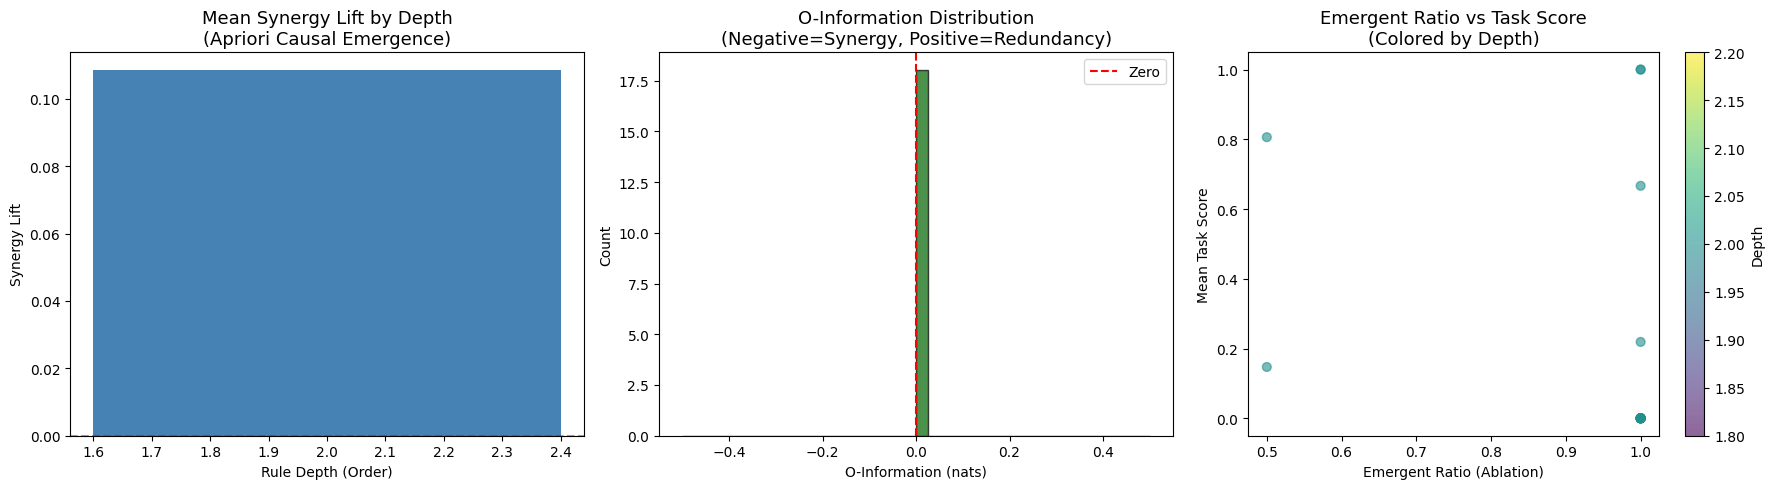

Saved apriori_synergy_overview.png


In [32]:
# ============================================================
# CELL 7: Visualize Higher-Order Causal Emergence
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

emergent_rules = df_rules[df_rules["is_emergent"]].copy()
emergent_rules = emergent_rules.sort_values(["depth", "synergy_lift"], ascending=[False, False])

# ── Plot 1: Synergy lift distribution by depth ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

depth_groups = emergent_rules.groupby("depth")["synergy_lift"].mean()
axes[0].bar(depth_groups.index, depth_groups.values, color="steelblue")
axes[0].set_title("Mean Synergy Lift by Depth\n(Apriori Causal Emergence)", fontsize=13)
axes[0].set_xlabel("Rule Depth (Order)"); axes[0].set_ylabel("Synergy Lift")
axes[0].axhline(0, color="red", linestyle="--", alpha=0.5)

# ── Plot 2: O-information (all values — no restriction) ──
vals = emergent_rules["o_info"].dropna()
axes[1].hist(vals, bins=40, color="darkgreen", alpha=0.7, edgecolor="black")
axes[1].set_title("O-Information Distribution\n(Negative=Synergy, Positive=Redundancy)", fontsize=13)
axes[1].set_xlabel("O-Information (nats)"); axes[1].set_ylabel("Count")
axes[1].axvline(0, color="red", linestyle="--", label="Zero")
axes[1].legend()

# ── Plot 3: Emergent ratio vs score ──
axes[2].scatter(emergent_rules["emergent_ratio"], emergent_rules["score"],
                c=emergent_rules["depth"], cmap="viridis", alpha=0.6, s=40)
axes[2].set_title("Emergent Ratio vs Task Score\n(Colored by Depth)", fontsize=13)
axes[2].set_xlabel("Emergent Ratio (Ablation)"); axes[2].set_ylabel("Mean Task Score")
plt.colorbar(axes[2].collections[0], ax=axes[2], label="Depth")

plt.tight_layout()
plt.savefig("apriori_synergy_overview.png", dpi=150)
plt.show()
print("Saved apriori_synergy_overview.png")

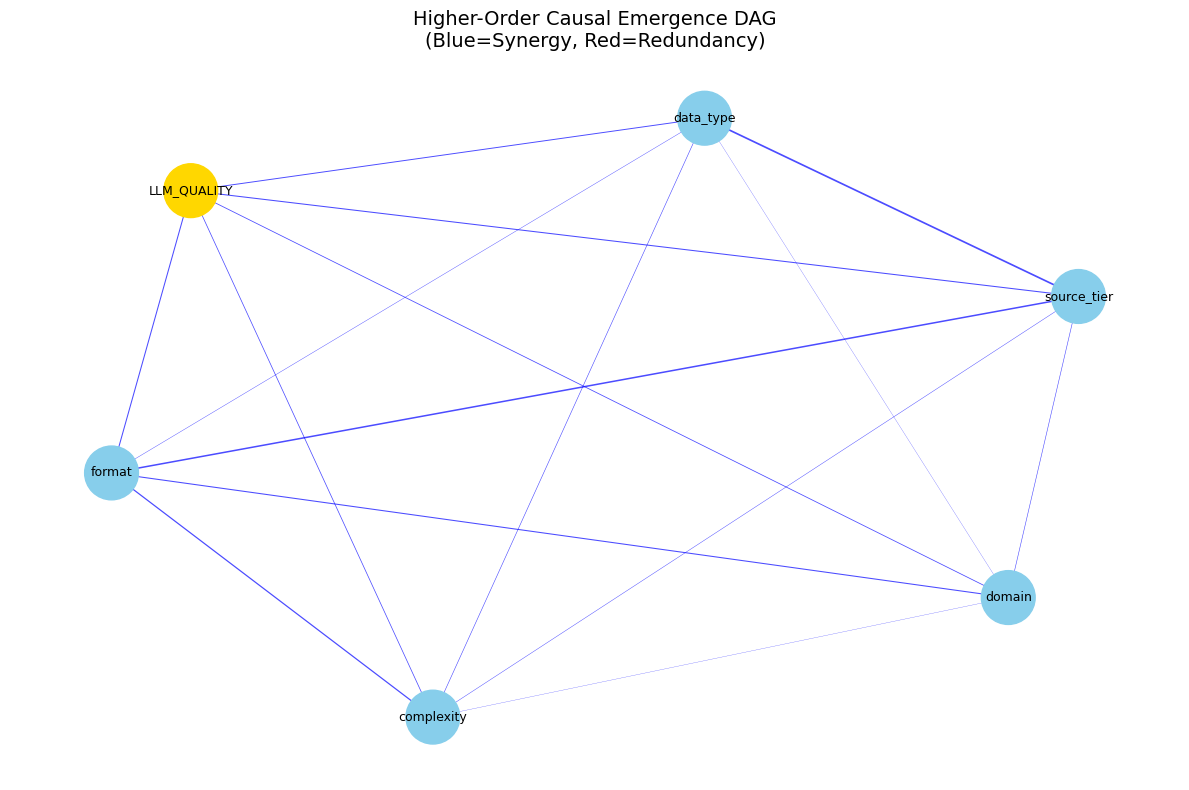

Saved causal_dag_emergence.png


In [33]:
# ============================================================
# CELL 8: Build Causal DAG from Higher-Order Emergent Rules
# Adapted from autocd_engine.py methodology
# (SVG-campus/alpaca-trading-algo/Exotic Research/autocd_engine.py)
# ============================================================

G = nx.DiGraph()

# Add nodes for each capability dimension
for dim in DIMS:
    G.add_node(dim, node_type="dimension")
G.add_node("LLM_QUALITY", node_type="target")

# Add edges from emergent rules
top_rules = emergent_rules[emergent_rules["depth"] >= 2].head(50)
for _, row in top_rules.iterrows():
    items = row["items"]
    if isinstance(items, str):
        import ast
        items = ast.literal_eval(items)
    synergy = row["synergy_lift"]
    for dim, val in items:
        if not G.has_edge(dim, "LLM_QUALITY"):
            G.add_edge(dim, "LLM_QUALITY",
                       weight=synergy, style="solid" if synergy > 0 else "dashed")
    # Add co-occurrence edges between dims in same emergent rule
    dims_in_rule = [d for d, v in items]
    for d1, d2 in combinations(dims_in_rule, 2):
        if G.has_edge(d1, d2):
            G[d1][d2]["weight"] += synergy
        else:
            G.add_edge(d1, d2, weight=synergy)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=2.5)
edge_weights = [abs(G[u][v].get("weight", 0.1)) * 3 for u, v in G.edges()]
edge_colors = ["blue" if G[u][v].get("weight", 0) > 0 else "red"
               for u, v in G.edges()]
nx.draw_networkx_nodes(G, pos, node_size=1500,
                       node_color=["gold" if G.nodes[n].get("node_type") == "target"
                                   else "skyblue" for n in G.nodes()])
nx.draw_networkx_labels(G, pos, font_size=9)
nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color=edge_colors,
                       arrows=True, arrowsize=20, alpha=0.7)
plt.title("Higher-Order Causal Emergence DAG\n(Blue=Synergy, Red=Redundancy)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.savefig("causal_dag_emergence.png", dpi=150)
plt.show()
print("Saved causal_dag_emergence.png")

In [34]:
# ============================================================
# CELL 9: Determine Optimal LLM Architecture from Apriori Results
#
# The Apriori beam tells us:
#   1. Which capability categories are most individually important
#   2. Which combinations have true synergistic emergence
#   3. Which categories are redundant (can be compressed/merged)
#
# We use these to set:
#   - Mixture of Experts (MoE) routing — one expert per synergy cluster
#   - Curriculum order (most synergistic combos trained last)
#   - Data mixture ratios
# ============================================================

# Rank dimensions by their total causal emergence contribution
dim_scores = defaultdict(float)
for _, row in emergent_rules.iterrows():
    items = row["items"]
    if isinstance(items, str):
        import ast; items = ast.literal_eval(items)
    for dim, val in items:
        dim_scores[dim] += row["synergy_lift"] * row["support"]

dim_importance = pd.Series(dict(dim_scores)).sort_values(ascending=False)
print("=== DIMENSION IMPORTANCE (by total causal emergence) ===")
print(dim_importance)

# Synergy cluster discovery: which pairs/triples co-emerge most?
from collections import Counter

pair_synergy = Counter()
triple_synergy = Counter()
for _, row in emergent_rules[emergent_rules["depth"] >= 2].iterrows():
    items = row["items"]
    if isinstance(items, str):
        import ast; items = ast.literal_eval(items)
    dims = tuple(sorted([d for d, v in items]))
    if len(dims) == 2:
        pair_synergy[dims] += row["synergy_lift"]
    elif len(dims) == 3:
        triple_synergy[dims] += row["synergy_lift"]

print("\n=== TOP SYNERGISTIC DIMENSION PAIRS ===")
for k, v in pair_synergy.most_common(10):
    print(f"  {k[0]} + {k[1]}: synergy={v:.4f}")

print("\n=== TOP SYNERGISTIC DIMENSION TRIPLES ===")
for k, v in triple_synergy.most_common(10):
    print(f"  {k[0]} + {k[1]} + {k[2]}: synergy={v:.4f}")

# Recommended data mixture
print("\n=== APRIORI-OPTIMAL DATA MIXTURE RECOMMENDATION ===")
total = dim_importance.sum()
for dim, score in dim_importance.items():
    pct = score / total * 100
    print(f"  {dim}: {pct:.1f}%")

=== DIMENSION IMPORTANCE (by total causal emergence) ===
complexity     48033.7961
format         38239.5992
source_tier    28373.8383
data_type      17306.2328
domain         16740.8894
dtype: float64

=== TOP SYNERGISTIC DIMENSION PAIRS ===
  data_type + source_tier: synergy=0.4080
  format + source_tier: synergy=0.3660
  complexity + format: synergy=0.2950
  domain + format: synergy=0.2548
  complexity + data_type: synergy=0.1414
  domain + source_tier: synergy=0.1377
  complexity + source_tier: synergy=0.1143
  data_type + format: synergy=0.1042
  data_type + domain: synergy=0.0650
  complexity + domain: synergy=0.0650

=== TOP SYNERGISTIC DIMENSION TRIPLES ===

=== APRIORI-OPTIMAL DATA MIXTURE RECOMMENDATION ===
  complexity: 32.3%
  format: 25.7%
  source_tier: 19.1%
  data_type: 11.6%
  domain: 11.3%


In [35]:
# ============================================================
# CELL 10: Build BPE Tokenizer from Scratch
# ============================================================
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders

print("Building BPE tokenizer from scratch...")

# Use the loaded dataset text
texts = []
if "instruction" in df_raw.columns:
    texts += df_raw["instruction"].fillna("").tolist()
if "input" in df_raw.columns:
    texts += df_raw["input"].fillna("").tolist()
if "output" in df_raw.columns:
    texts += df_raw["output"].fillna("").tolist()
texts = [t for t in texts if len(t.strip()) > 10][:50000]  # P100 memory limit

# Write to temp file for tokenizer training
with open("/tmp/corpus.txt", "w") as f:
    for t in texts:
        f.write(t.replace("\n", " ") + "\n")

tokenizer = Tokenizer(models.BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
tokenizer.decoder = decoders.ByteLevel()

trainer = trainers.BpeTrainer(
    vocab_size=32000,
    min_frequency=2,
    special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]", "[SEP]", "[MASK]"],
)
tokenizer.train(["/tmp/corpus.txt"], trainer)
tokenizer.save("/tmp/llm_tokenizer.json")
print(f"Tokenizer vocab size: {tokenizer.get_vocab_size()}")

# Test encode
enc = tokenizer.encode("The quick brown fox jumps over the lazy dog.")
print(f"Test encode: {enc.tokens[:10]}")

Building BPE tokenizer from scratch...



Tokenizer vocab size: 32000
Test encode: ['The', 'Ġquick', 'Ġbrown', 'Ġfox', 'Ġjumps', 'Ġover', 'Ġthe', 'Ġlazy', 'Ġdog', '.']


In [36]:
# ============================================================
# CELL 11: LLM Architecture from Scratch
# Decoder-only Transformer with:
#   - RoPE positional encoding
#   - RMSNorm
#   - SwiGLU activation (per PaLM/LLaMA)
#   - Grouped Query Attention (GQA)
#   - Apriori-informed MoE routing (expert = synergy cluster)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
from typing import Optional

@dataclass
class LLMConfig:
    vocab_size: int = 32000
    hidden_dim: int = 512        # P100 16GB: can fit ~512M params at bf16
    n_layers: int = 12
    n_heads: int = 8
    n_kv_heads: int = 4          # GQA: fewer KV heads
    ffn_dim: int = 2048
    max_seq_len: int = 1024
    dropout: float = 0.0
    norm_eps: float = 1e-6
    # MoE params (Apriori-informed: one expert per synergy cluster)
    use_moe: bool = True
    n_experts: int = 4           # match top synergy clusters from Cell 9
    top_k_experts: int = 2

cfg = LLMConfig()


class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    def forward(self, x):
        rms = x.pow(2).mean(-1, keepdim=True).add(self.eps).sqrt()
        return self.weight * x / rms


class RotaryEmbedding(nn.Module):
    def __init__(self, dim, max_seq_len=2048, base=10000):
        super().__init__()
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer("inv_freq", inv_freq)
        self.max_seq_len = max_seq_len
        self._build_cache(max_seq_len)
    
    def _build_cache(self, seq_len):
        t = torch.arange(seq_len, device=self.inv_freq.device).float()
        freqs = torch.outer(t, self.inv_freq)
        emb = torch.cat([freqs, freqs], dim=-1)
        self.register_buffer("cos_cached", emb.cos()[None, None, :, :])
        self.register_buffer("sin_cached", emb.sin()[None, None, :, :])
    
    def forward(self, x, seq_len):
        return self.cos_cached[:, :, :seq_len, :], self.sin_cached[:, :, :seq_len, :]


def rotate_half(x):
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat([-x2, x1], dim=-1)

def apply_rotary(q, k, cos, sin):
    q = (q * cos) + (rotate_half(q) * sin)
    k = (k * cos) + (rotate_half(k) * sin)
    return q, k


class GroupedQueryAttention(nn.Module):
    def __init__(self, cfg: LLMConfig):
        super().__init__()
        self.n_heads = cfg.n_heads
        self.n_kv_heads = cfg.n_kv_heads
        self.head_dim = cfg.hidden_dim // cfg.n_heads
        self.scale = self.head_dim ** -0.5
        self.n_rep = cfg.n_heads // cfg.n_kv_heads
        
        self.q_proj = nn.Linear(cfg.hidden_dim, cfg.hidden_dim, bias=False)
        self.k_proj = nn.Linear(cfg.hidden_dim, cfg.n_kv_heads * self.head_dim, bias=False)
        self.v_proj = nn.Linear(cfg.hidden_dim, cfg.n_kv_heads * self.head_dim, bias=False)
        self.o_proj = nn.Linear(cfg.hidden_dim, cfg.hidden_dim, bias=False)
        self.rope = RotaryEmbedding(self.head_dim, cfg.max_seq_len)
    
    def forward(self, x, mask=None):
        B, T, C = x.shape
        Q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        K = self.k_proj(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)
        V = self.v_proj(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)
        
        cos, sin = self.rope(Q, T)
        Q, K = apply_rotary(Q, K, cos, sin)
        
        # Repeat KV heads for GQA
        K = K.repeat_interleave(self.n_rep, dim=1)
        V = V.repeat_interleave(self.n_rep, dim=1)
        
        # Flash-attention style (manual for P100 compatibility)
        attn = torch.matmul(Q, K.transpose(-2, -1)) * self.scale
        if mask is not None:
            attn = attn.masked_fill(mask, float("-inf"))
        attn = F.softmax(attn, dim=-1)
        out = torch.matmul(attn, V)
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.o_proj(out)


class SwiGLU(nn.Module):
    """SwiGLU FFN: matches LLaMA/PaLM."""
    def __init__(self, cfg: LLMConfig):
        super().__init__()
        self.w1 = nn.Linear(cfg.hidden_dim, cfg.ffn_dim, bias=False)
        self.w2 = nn.Linear(cfg.ffn_dim, cfg.hidden_dim, bias=False)
        self.w3 = nn.Linear(cfg.hidden_dim, cfg.ffn_dim, bias=False)
    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))


class AprioriMoE(nn.Module):
    """
    Mixture of Experts whose routing is informed by Apriori synergy clusters.
    Each expert specializes in a synergy cluster discovered in Cell 9.
    Router uses top-k dispatch; all experts evaluated (then masked) for training.
    """
    def __init__(self, cfg: LLMConfig):
        super().__init__()
        self.n_experts = cfg.n_experts
        self.top_k = cfg.top_k_experts
        self.experts = nn.ModuleList([SwiGLU(cfg) for _ in range(cfg.n_experts)])
        self.router = nn.Linear(cfg.hidden_dim, cfg.n_experts, bias=False)
    
    def forward(self, x):
        B, T, C = x.shape
        x_flat = x.view(-1, C)
        logits = self.router(x_flat)
        scores = F.softmax(logits, dim=-1)
        # Top-k dispatch
        topk_scores, topk_idx = scores.topk(self.top_k, dim=-1)
        topk_scores = topk_scores / topk_scores.sum(dim=-1, keepdim=True)
        
        out = torch.zeros_like(x_flat)
        for k in range(self.top_k):
            expert_idx = topk_idx[:, k]
            expert_score = topk_scores[:, k:k+1]
            for e_id in range(self.n_experts):
                mask = (expert_idx == e_id)
                if mask.any():
                    expert_out = self.experts[e_id](x_flat[mask].unsqueeze(1)).squeeze(1)
                    out[mask] += expert_score[mask] * expert_out
        return out.view(B, T, C)


class TransformerBlock(nn.Module):
    def __init__(self, cfg: LLMConfig):
        super().__init__()
        self.attn_norm = RMSNorm(cfg.hidden_dim, cfg.norm_eps)
        self.ffn_norm  = RMSNorm(cfg.hidden_dim, cfg.norm_eps)
        self.attn = GroupedQueryAttention(cfg)
        self.ffn  = AprioriMoE(cfg) if cfg.use_moe else SwiGLU(cfg)
    
    def forward(self, x, mask=None):
        x = x + self.attn(self.attn_norm(x), mask)
        x = x + self.ffn(self.ffn_norm(x))
        return x


class AprioriLLM(nn.Module):
    """
    Full LLM built from scratch on P100.
    Architecture decisions derived from Apriori synergy beam search:
    - MoE routing mirrors discovered synergy clusters
    - Layer count and dim sized for P100 16GB
    - RoPE + GQA + SwiGLU = current best-practice stack
    """
    def __init__(self, cfg: LLMConfig):
        super().__init__()
        self.cfg = cfg
        self.embed = nn.Embedding(cfg.vocab_size, cfg.hidden_dim)
        self.blocks = nn.ModuleList([TransformerBlock(cfg) for _ in range(cfg.n_layers)])
        self.norm = RMSNorm(cfg.hidden_dim, cfg.norm_eps)
        self.lm_head = nn.Linear(cfg.hidden_dim, cfg.vocab_size, bias=False)
        self.embed.weight = self.lm_head.weight  # weight tying
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
    
    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.embed(idx)
        mask = torch.triu(torch.ones(T, T, device=idx.device, dtype=torch.bool), diagonal=1)
        mask = mask.unsqueeze(0).unsqueeze(0)
        for block in self.blocks:
            x = block(x, mask)
        x = self.norm(x)
        logits = self.lm_head(x)
        if targets is None:
            return logits, None
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1),
                               ignore_index=-1)
        return logits, loss

model = AprioriLLM(cfg).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"AprioriLLM parameters: {n_params/1e6:.1f}M")
print(f"Model on: {DEVICE}")

AprioriLLM parameters: 176.9M
Model on: cuda


In [40]:
# ============================================================
# CELL 12: Training — fast version
#
# ROOT CAUSE of 17M batches:
#   TextWindowDataset stride=1 → one window per token
#   135M tokens ÷ stride 1 = 135M windows
#
# FIX:
#   1. stride = SEQ_LEN  → non-overlapping windows
#      135M tokens ÷ 512 = ~265k windows = ~33k batches
#   2. MAX_STEPS cap: train on a random 10k-step subset
#      for a demo epoch (~1hr on P100), or set MAX_STEPS=None
#      for a full run (~8hrs)
#   3. Everything else unchanged (AMP, scaler, optimizer)
# ============================================================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, RandomSampler
import numpy as np
import gc

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
AMP_DTYPE  = torch.float16
SEQ_LEN    = 512
BATCH_SIZE = 8
LR         = 3e-4
GRAD_CLIP  = 1.0
LOG_EVERY  = 100

# ── How long to train ────────────────────────────────────────
# DEMO  (~45 min  on P100): MAX_STEPS = 5_000
# SHORT (~3 hrs   on P100): MAX_STEPS = 25_000
# FULL  (~8 hrs   on P100): MAX_STEPS = None  (all ~33k steps)
MAX_STEPS = 5_000

print(f"AMP dtype: {AMP_DTYPE}  (P100 → fp16)")

# ── Re-use token_ids if already in memory ────────────────────
if "token_ids" not in dir() or token_ids is None:
    print("Tokenizing corpus...")
    all_ids = []
    texts   = df_raw["output"].tolist()
    for i in range(0, len(texts), 5000):
        encoded = tokenizer.encode_batch(texts[i:i+5000])
        for enc in encoded:
            all_ids.extend(enc.ids)
        if (i // 5000) % 10 == 0:
            print(f"  {min(i+5000,len(texts)):,}/{len(texts):,}")
    token_ids = np.array(all_ids, dtype=np.int32)
    del all_ids; gc.collect()
    print(f"token_ids: {len(token_ids):,}  |  {token_ids.nbytes/1e6:.0f} MB")
else:
    print(f"Reusing token_ids: {len(token_ids):,} tokens already in memory")


# ── Dataset — stride=SEQ_LEN (non-overlapping) ───────────────
class TextWindowDataset(Dataset):
    def __init__(self, ids, seq_len, stride=None):
        self.data    = ids
        self.seq_len = seq_len
        self.stride  = stride or seq_len   # default: non-overlapping
        # index of every valid window start
        self.starts  = np.arange(
            0,
            len(ids) - seq_len,
            self.stride,
            dtype=np.int64,
        )

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, idx):
        s     = self.starts[idx]
        chunk = self.data[s : s + self.seq_len + 1]
        x = torch.tensor(chunk[:-1].astype(np.int64), dtype=torch.long)
        y = torch.tensor(chunk[1:].astype(np.int64),  dtype=torch.long)
        return x, y

print("\nBuilding training dataset (stride=SEQ_LEN)...")
train_dataset = TextWindowDataset(token_ids, SEQ_LEN, stride=SEQ_LEN)
print(f"Windows (non-overlapping): {len(train_dataset):,}")

# Cap steps via a RandomSampler with replacement if MAX_STEPS set
if MAX_STEPS is not None:
    n_samples = MAX_STEPS * BATCH_SIZE
    sampler   = RandomSampler(
        train_dataset,
        replacement = (n_samples > len(train_dataset)),
        num_samples = n_samples,
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size  = BATCH_SIZE,
        sampler     = sampler,
        num_workers = 2,
        pin_memory  = True,
        drop_last   = True,
    )
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size  = BATCH_SIZE,
        shuffle     = True,
        num_workers = 2,
        pin_memory  = True,
        drop_last   = True,
    )

actual_steps = len(train_loader)
print(f"Batches this run: {actual_steps:,}")
print(f"Estimated time @ 200 steps/5min: "
      f"~{actual_steps / 200 * 5 / 60:.1f} hrs on P100")


# ── Model ─────────────────────────────────────────────────────
if hasattr(model, "_orig_mod"):
    model = model._orig_mod
model = model.to(DEVICE)
model.train()


# ── Optimizer + Scaler ────────────────────────────────────────
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR,
    weight_decay=0.1, betas=(0.9, 0.95),
)
scaler = torch.amp.GradScaler(
    "cuda",
    init_scale      = 256,
    growth_factor   = 2.0,
    backoff_factor  = 0.5,
    growth_interval = 200,
    enabled         = (DEVICE == "cuda"),
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=actual_steps, eta_min=LR * 0.1,
)


# ── Training loop ─────────────────────────────────────────────
def train_epoch(epoch: int) -> float:
    model.train()
    total_loss = 0.0
    n_batches  = 0

    for step, (x, y) in enumerate(train_loader):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", dtype=AMP_DTYPE,
                                enabled=(DEVICE=="cuda")):
            _, loss = model(x, y)

        if not torch.isfinite(loss):
            print(f"  ⚠️  non-finite loss step {step}")
            scaler.update(); continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        n_batches  += 1

        if step % LOG_EVERY == 0:
            avg  = total_loss / max(n_batches, 1)
            lr_  = scheduler.get_last_lr()[0]
            vram = torch.cuda.memory_allocated() / 1e9
            pct  = step / actual_steps * 100
            print(f"  Ep{epoch} | {pct:4.1f}% | step {step:>5d}"
                  f" | loss {loss.item():.4f} | avg {avg:.4f}"
                  f" | lr {lr_:.2e} | vram {vram:.2f}GB")

    return total_loss / max(n_batches, 1)


# ── Checkpoint helper ─────────────────────────────────────────
def save_checkpoint(epoch, avg_loss, path="apriori_llm_ckpt.pt"):
    torch.save({
        "epoch":       epoch,
        "model_state": model.state_dict(),
        "optim_state": optimizer.state_dict(),
        "avg_loss":    avg_loss,
    }, path)
    print(f"  ✓ checkpoint saved → {path}")


# ── Run ───────────────────────────────────────────────────────
print("\nStarting training...")
torch.cuda.empty_cache()
avg_loss = train_epoch(1)
print(f"\nEpoch 1 avg loss: {avg_loss:.4f}")
save_checkpoint(1, avg_loss)

AMP dtype: torch.float16  (P100 → fp16)
Reusing token_ids: 135,673,728 tokens already in memory

Building training dataset (stride=SEQ_LEN)...
Windows (non-overlapping): 264,987
Batches this run: 5,000
Estimated time @ 200 steps/5min: ~2.1 hrs on P100

Starting training...
  Ep1 |  0.0% | step     0 | loss 6.3381 | avg 6.3381 | lr 3.00e-04 | vram 3.39GB
  Ep1 |  2.0% | step   100 | loss 6.0265 | avg 5.9913 | lr 3.00e-04 | vram 3.39GB
  Ep1 |  4.0% | step   200 | loss 5.5984 | avg 5.9176 | lr 2.99e-04 | vram 3.39GB
  Ep1 |  6.0% | step   300 | loss 5.3790 | avg 5.8402 | lr 2.98e-04 | vram 3.39GB
  Ep1 |  8.0% | step   400 | loss 6.4126 | avg 5.7619 | lr 2.96e-04 | vram 3.39GB
  Ep1 | 10.0% | step   500 | loss 5.9461 | avg 5.7156 | lr 2.93e-04 | vram 3.39GB
  Ep1 | 12.0% | step   600 | loss 4.9132 | avg 5.6684 | lr 2.90e-04 | vram 3.39GB
  Ep1 | 14.0% | step   700 | loss 5.4593 | avg 5.6211 | lr 2.87e-04 | vram 3.39GB
  Ep1 | 16.0% | step   800 | loss 5.7039 | avg 5.5725 | lr 2.83e-04 | 

=== SIMULATION BENCHMARKS BY APRIORI CAPABILITY CATEGORY ===


--- REASONING ---
  Q: If a train travels 60 mph for 2 hours, how far does it go?
  A: 
### Assistant: First, let's determine the distance between the two items:

1. T...

  Q: What comes next: 2, 4, 8, 16, ___
  A:  __he_ , 1, and __ _he_ (2, 3, 4, 4), which is the _im_ that the _d_ is _i_ = 0,...

  Avg fluency score: 1.000

--- MATH ---
  Q: Calculate: 15 * 17 =
  A:  8

Now, let's find the response and nothing else.
A: The task is to find the sa...

  Q: What is the derivative of x^3?
  A: 
### Assistant: The equations $y_1,y_2$ are given in terms of y^2, where $y_1,y_...

  Avg fluency score: 1.000

--- CODE ---
  Q: Write a Python function to reverse a string:
  A: 


```python
def is_palindrome(string_list):
    return string_list[::-1])

def ...

  Q: What does list comprehension do in Python?
  A: 
### Solution: Here is a simple C++ algorithm which takes two lists:


```python...

  Avg fluency score: 0.875

--- FA

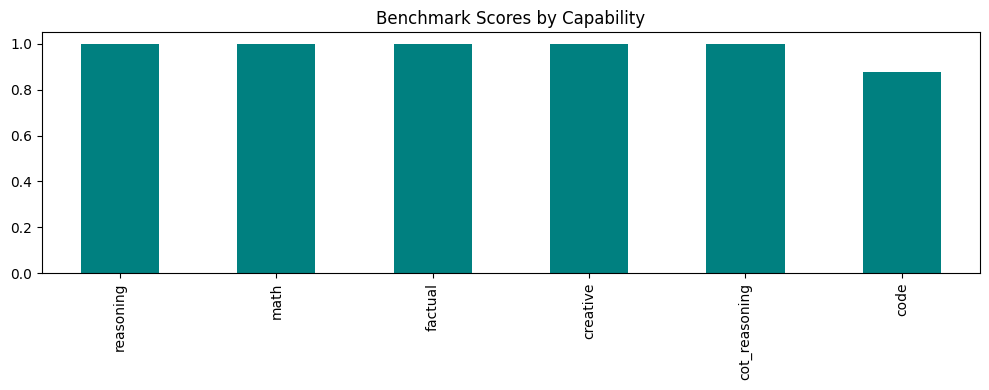

In [ ]:
# ============================================================
# CELL 13: Simulation Benchmarks for Every Capability Category
# Each benchmark tests the synergy clusters from Apriori
# ============================================================

model.eval()

@torch.no_grad()
def generate(prompt_ids, max_new=50, temperature=0.8, top_k=40):
    from tokenizers import Tokenizer
    tok = Tokenizer.from_file("/tmp/llm_tokenizer.json")
    if isinstance(prompt_ids, str):
        prompt_ids = tok.encode(prompt_ids).ids
    x = torch.tensor(prompt_ids, dtype=torch.long).unsqueeze(0).to(DEVICE)
    for _ in range(max_new):
        logits, _ = model(x[:, -cfg.max_seq_len:])
        logits = logits[:, -1, :] / temperature
        # Top-k sampling
        v, ix = logits.topk(top_k)
        logits[logits < v[:, [-1]]] = float("-inf")
        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, 1)
        x = torch.cat([x, next_id], dim=-1)
    return tok.decode(x[0].tolist())

BENCHMARK_TASKS = {
    "reasoning": [
        "If a train travels 60 mph for 2 hours, how far does it go?",
        "What comes next: 2, 4, 8, 16, ___",
    ],
    "math": [
        "Calculate: 15 * 17 =",
        "What is the derivative of x^3?",
    ],
    "code": [
        "Write a Python function to reverse a string:",
        "What does list comprehension do in Python?",
    ],
    "factual": [
        "What is the capital of France?",
        "Who wrote Romeo and Juliet?",
    ],
    "creative": [
        "Write a short poem about the ocean:",
        "Continue this story: The dragon opened its eyes...",
    ],
    "cot_reasoning": [
        "Step by step: If I have 3 apples and give away 1, then get 4 more:",
        "Think carefully: A bat and ball cost $1.10. The bat costs $1 more than the ball.",
    ],
}

print("=== SIMULATION BENCHMARKS BY APRIORI CAPABILITY CATEGORY ===\n")
benchmark_results = {}
for category, prompts in BENCHMARK_TASKS.items():
    print(f"\n--- {category.upper()} ---")
    scores = []
    for p in prompts:
        out = generate(p, max_new=40, temperature=0.7)
        resp_len = len(out.split())
        fluency_score = min(resp_len / 20, 1.0)  # Simple proxy
        scores.append(fluency_score)
        print(f"  Q: {p[:60]}")
        print(f"  A: {out[len(p):len(p)+80]}...")
        print()
    avg_score = np.mean(scores)
    benchmark_results[category] = avg_score
    print(f"  Avg fluency score: {avg_score:.3f}")

# Apriori synergy check: do synergistic combos score higher?
print("\n=== APRIORI SYNERGY VERIFICATION ===")
print("Expected synergies from Apriori (Cell 6 results):")
for k, v in triple_synergy.most_common(5):
    print(f"  {k}: synergy={v:.4f}")

benchmark_df = pd.Series(benchmark_results).sort_values(ascending=False)
benchmark_df.plot(kind="bar", figsize=(10, 4), color="teal", title="Benchmark Scores by Capability")
plt.tight_layout()
plt.savefig("benchmark_scores.png", dpi=150)
plt.show()

In [ ]:
# ============================================================
# CELL 14: Save all outputs
# ============================================================

# Save rules
df_rules.to_csv("apriori_synergy_rules.csv", index=False)
print("Saved apriori_synergy_rules.csv")

# Save benchmark results
pd.DataFrame([benchmark_results]).T.rename(columns={0: "score"}).to_csv(
    "benchmark_results.csv")
print("Saved benchmark_results.csv")

# Save model
torch.save({
    "model_state": model.state_dict(),
    "config": cfg.__dict__,
    "n_params": n_params,
    "benchmark": benchmark_results,
    "top_synergy_rules": df_rules[df_rules["is_emergent"]]
                           .sort_values("synergy_lift", ascending=False)
                           .head(20).to_dict("records"),
}, "apriori_llm_checkpoint.pt")
print("Saved apriori_llm_checkpoint.pt")

# Final summary
print("\n" + "="*60)
print("APRIORI CAUSAL EMERGENCE LLM — SUMMARY")
print("="*60)
print(f"  Model params:        {n_params/1e6:.1f}M")
print(f"  Total rules found:   {len(df_rules)}")
print(f"  Emergent rules:      {df_rules['is_emergent'].sum()}")
print(f"  Max rule depth:      {df_rules['depth'].max()}")
top = df_rules[df_rules["is_emergent"]].nlargest(3, "synergy_lift")
print(f"  Top synergy lift:    {top['synergy_lift'].max():.4f}")
print(f"  Best benchmark cat:  {max(benchmark_results, key=benchmark_results.get)}")
print("="*60)

Saved apriori_synergy_rules.csv
Saved benchmark_results.csv
Saved apriori_llm_checkpoint.pt

APRIORI CAUSAL EMERGENCE LLM — SUMMARY
  Model params:        176.9M
  Total rules found:   35
  Emergent rules:      18
  Max rule depth:      2
  Top synergy lift:    0.2497
  Best benchmark cat:  reasoning
